# Road Follower - Train Model

In this notebook we will train a neural network to take an input image, and output a set of x, y values corresponding to a target.

We will be using PyTorch deep learning framework to train ResNet18 neural network architecture model for road follower application.

In [1]:
import torch
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.datasets as datasets
import torchvision.models as models
import torchvision.transforms as transforms
import glob
import PIL.Image
import os
import numpy as np
import pandas as pd

DATASET_NAME = 'dataset_labeled_2'
DATASET_DIR = 'datasets/' + DATASET_NAME

### Create Dataset Instance

Here we create a custom ``torch.utils.data.Dataset`` implementation, which implements the ``__len__`` and ``__getitem__`` functions.  This class
is responsible for loading images and parsing the x, y values from the image filenames.  Because we implement the ``torch.utils.data.Dataset`` class,
we can use all of the torch data utilities :)

We hard coded some transformations (like color jitter) into our dataset.  We made random horizontal flips optional (in case you want to follow a non-symmetric path, like a road
where we need to 'stay right').  If it doesn't matter whether your robot follows some convention, you could enable flips to augment the dataset.

In [2]:
_label_cache = {}
def _load_labels(csv_file):
    if csv_file not in _label_cache:
        df = pd.read_csv(csv_file)
        _label_cache[csv_file] = {os.path.basename(r['image_path']): (r['x_norm'], r['y_norm']) for _, r in df.iterrows()}
    return _label_cache[csv_file]

def get_x(path, width, csv_file=f'{DATASET_DIR}/labels.csv'):
    return _load_labels(csv_file)[os.path.basename(path)][0]

def get_y(path, height, csv_file=f'{DATASET_DIR}/labels.csv'):
    return _load_labels(csv_file)[os.path.basename(path)][1]


def augment_image(image, x, y, max_crop=0.8):
    W, H = image.size

    scale = np.random.uniform(max_crop, 1.0)

    crop_w = int(W * scale)
    crop_h = int(H * scale)

    left = np.random.randint(0, W - crop_w + 1)
    top = np.random.randint(0, H - crop_h + 1)

    image = transforms.functional.crop(image, top, left, crop_h, crop_w)

    x_pix = x * W
    y_pix = y * H

    x_new = (x_pix - left) / crop_w
    y_new = (y_pix - top) / crop_h

    image = transforms.functional.resize(image, (H, W))

    return image, x_new, y_new

class XYDataset(torch.utils.data.Dataset):
    
    def __init__(self, directory, random_hflips=False, augment=False):
        self.directory = directory
        self.random_hflips = random_hflips
        self.augment = augment
        self.image_paths = glob.glob(os.path.join(self.directory, '*.jpg'))
        self.color_jitter = transforms.ColorJitter(0.3, 0.3, 0.3, 0.3)
    
    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]

        image = PIL.Image.open(image_path)
        width, height = image.size
        x = float(get_x(os.path.basename(image_path), width))
        y = float(get_y(os.path.basename(image_path), height))
        
        if self.random_hflips and float(np.random.rand(1)) > 0.5:
            image = transforms.functional.hflip(image)
            x = 1 - x

        if self.augment:
            image, x, y = augment_image(image, x, y)
        
        image = self.color_jitter(image)
        image = transforms.functional.resize(image, (224, 224))
        image = transforms.functional.to_tensor(image)
        image = image.numpy()[::-1].copy()
        image = torch.from_numpy(image)
        image = transforms.functional.normalize(image, [0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        
        return image, torch.tensor([x, y]).float()

dataset = XYDataset(DATASET_DIR, random_hflips=True, augment=True)

# Training

In [3]:
train_p, val_p, test_p = 0.8, 0.1, 0.1
num_train = int(train_p * len(dataset))
num_val = int(val_p * len(dataset))
num_test = len(dataset) - num_train - num_val
train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(dataset, [num_train, num_val, num_test])

In [4]:
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0
)

In [5]:
model = models.resnet18(pretrained=True)

In [7]:
model.fc = torch.nn.Linear(512, 2)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
print(device)
BEST_MODEL_PATH = f'models/{DATASET_NAME}/best_steering_model_xy.pth'

cuda


In [8]:
NUM_EPOCHS = 70
os.makedirs(f'models/{DATASET_NAME}', exist_ok=True)
BEST_MODEL_PATH = f'models/{DATASET_NAME}/best_steering_model_xy.pth'
best_loss = 1e9
optimizer = optim.Adam(model.parameters())

for epoch in range(NUM_EPOCHS):
    model.train()
    train_loss = 0.0
    train_mae = 0.0
    for images, labels in iter(train_loader):
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = F.mse_loss(outputs, labels)
        train_loss += float(loss)
        train_mae += float(F.l1_loss(outputs, labels))
        loss.backward()
        optimizer.step()
    train_loss /= len(train_loader)
    train_mae /= len(train_loader)

    model.eval()
    val_loss = 0.0
    val_mae = 0.0
    val_euclidean = 0.0
    with torch.no_grad():
        for images, labels in iter(val_loader):
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            val_loss += float(F.mse_loss(outputs, labels))
            val_mae += float(F.l1_loss(outputs, labels))
            # Euclidean distance between predicted and true (x, y)
            val_euclidean += float(torch.mean(torch.sqrt(torch.sum((outputs - labels) ** 2, dim=1))))
    val_loss /= len(val_loader)
    val_mae /= len(val_loader)
    val_euclidean /= len(val_loader)

    print('Epoch %d/%d — Train Loss: %.4f, Train MAE: %.4f | Val Loss: %.4f, Val MAE: %.4f, Val Dist: %.4f'
          % (epoch + 1, NUM_EPOCHS, train_loss, train_mae, val_loss, val_mae, val_euclidean))

    if val_loss < best_loss:
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        best_loss = val_loss

Epoch 1/70 — Train Loss: 0.3774, Train MAE: 0.4226 | Val Loss: 0.1762, Val MAE: 0.3099, Val Dist: 0.5080
Epoch 2/70 — Train Loss: 0.0349, Train MAE: 0.1480 | Val Loss: 0.0326, Val MAE: 0.1520, Val Dist: 0.2443
Epoch 3/70 — Train Loss: 0.0311, Train MAE: 0.1421 | Val Loss: 0.0198, Val MAE: 0.1136, Val Dist: 0.1812
Epoch 4/70 — Train Loss: 0.0206, Train MAE: 0.1140 | Val Loss: 0.0061, Val MAE: 0.0613, Val Dist: 0.0960
Epoch 5/70 — Train Loss: 0.0273, Train MAE: 0.1304 | Val Loss: 0.0131, Val MAE: 0.0919, Val Dist: 0.1448
Epoch 6/70 — Train Loss: 0.0172, Train MAE: 0.1047 | Val Loss: 0.0215, Val MAE: 0.1166, Val Dist: 0.1937
Epoch 7/70 — Train Loss: 0.0149, Train MAE: 0.0929 | Val Loss: 0.0114, Val MAE: 0.0825, Val Dist: 0.1302
Epoch 8/70 — Train Loss: 0.0141, Train MAE: 0.0951 | Val Loss: 0.0113, Val MAE: 0.0858, Val Dist: 0.1410
Epoch 9/70 — Train Loss: 0.0114, Train MAE: 0.0856 | Val Loss: 0.0145, Val MAE: 0.0781, Val Dist: 0.1248
Epoch 10/70 — Train Loss: 0.0119, Train MAE: 0.0853 | V

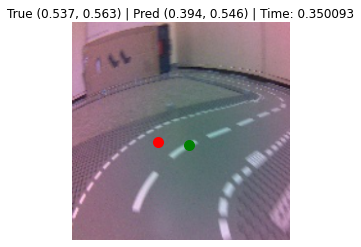

True x: 0.537, True y: 0.563
Pred x: 0.394, Pred y: 0.546
Prediction time: 0.350093


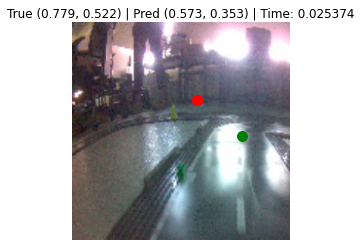

True x: 0.779, True y: 0.522
Pred x: 0.573, Pred y: 0.353
Prediction time: 0.025374


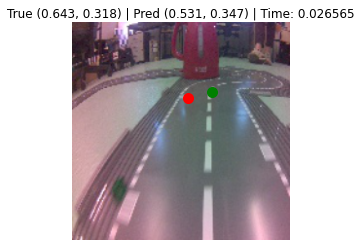

True x: 0.643, True y: 0.318
Pred x: 0.531, Pred y: 0.347
Prediction time: 0.026565
avg inferences per second:  7.462092569745692


In [9]:
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import torch
import PIL.Image
import os
import torchvision.transforms as transforms
from datetime import datetime


def get_image_tensor(image_path):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),   # ResNet expects 224x224
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],   # ImageNet mean
                             [0.229, 0.224, 0.225])    # ImageNet std
    ])
    image = PIL.Image.open(image_path).convert('RGB')
    return transform(image)

model = models.resnet18(pretrained=False)
model.fc = torch.nn.Linear(512, 2)
state_dict = torch.load(BEST_MODEL_PATH, map_location='cpu')
model.load_state_dict(state_dict)
model.eval()

samples = [dataset.image_paths[i] for i in test_loader.dataset.indices]
random.shuffle(samples)

prediction_times = []
for s in samples[:3]:
    image = PIL.Image.open(s)
    width, height = image.size
    
    true_x = get_x(os.path.basename(s), width)
    true_y = get_y(os.path.basename(s), height)

    image, true_x, true_y = augment_image(image, true_x, true_y, max_crop=0.6)
    
    time = datetime.now()
    with torch.no_grad():
        output = model(get_image_tensor(s).unsqueeze(0))[0].numpy()

    prediction_time = (datetime.now() - time).total_seconds()
    prediction_times.append(prediction_time)

    pred_x, pred_y = output[0], output[1]
    
    plt.figure(figsize=(4, 4))
    plt.imshow(image)
    plt.title(f"True ({true_x:.3f}, {true_y:.3f}) | Pred ({pred_x:.3f}, {pred_y:.3f}) | Time: {prediction_time}")
    plt.scatter(true_x * width, true_y * height, color='green', label='True', s=100)
    plt.scatter(pred_x * width, pred_y * height, color='red', label='Pred', s=100)
    plt.axis('off')
    plt.show()
    
    print(f"True x: {true_x:.3f}, True y: {true_y:.3f}")
    print(f"Pred x: {pred_x:.3f}, Pred y: {pred_y:.3f}")
    print(f"Prediction time: {prediction_time}")

print("avg inferences per second: ", 1 / np.mean(prediction_times))

Once the model is trained, it will generate ``best_steering_model_xy.pth`` file which you can use for inferencing in the live demo notebook.

If you trained on a different machine other than JetBot, you'll need to upload this to the JetBot to the ``road_following`` example folder.

In [10]:
import torch
state_dict = torch.load(BEST_MODEL_PATH, map_location='cpu')
torch.save(state_dict, f'models/{DATASET_NAME}/model_to_import.pth', _use_new_zipfile_serialization=False)

# Jetbot test
test with the live_demo script


In [132]:
MODEL_PATH = 'models/dataset_labeled_2/model_to_import.pth'

import torchvision
import torch

model_speed = torchvision.models.resnet18(pretrained=False)
model_speed.fc = torch.nn.Linear(512, 2)
model_speed.load_state_dict(torch.load(MODEL_PATH))
model_speed.eval()

model_speed.load_state_dict(torch.load(MODEL_PATH))

device = torch.device('cuda')
model_speed = model_speed.to(device)
model_speed = model_speed.eval().half()

import torchvision.transforms as transforms
import torch.nn.functional as F
import PIL.Image
import numpy as np
import ipywidgets


mean = torch.Tensor([0.485, 0.456, 0.406]).cuda().half()
std = torch.Tensor([0.229, 0.224, 0.225]).cuda().half()


speed_gain_slider = ipywidgets.FloatSlider(min=0.0, max=1.0, step=0.01, description='speed gain')
steering_gain_slider = ipywidgets.FloatSlider(min=0.0, max=1.0, step=0.01, value=0.2, description='steering gain')
steering_dgain_slider = ipywidgets.FloatSlider(min=0.0, max=0.5, step=0.001, value=0.0, description='steering kd')
steering_bias_slider = ipywidgets.FloatSlider(min=-0.3, max=0.3, step=0.01, value=0.0, description='steering bias')

display(speed_gain_slider, steering_gain_slider, steering_dgain_slider, steering_bias_slider)

FloatSlider(value=0.0, description='speed gain', max=1.0, step=0.01)

FloatSlider(value=0.2, description='steering gain', max=1.0, step=0.01)

FloatSlider(value=0.0, description='steering kd', max=0.5, step=0.001)

FloatSlider(value=0.0, description='steering bias', max=0.3, min=-0.3, step=0.01)

In [120]:
x_slider = ipywidgets.FloatSlider(min=-1.0, max=1.0, description='x')
y_slider = ipywidgets.FloatSlider(min=0, max=1.0, orientation='vertical', description='y')
steering_slider = ipywidgets.FloatSlider(min=-1.0, max=1.0, description='steering')
speed_slider = ipywidgets.FloatSlider(min=0, max=1.0, orientation='vertical', description='speed')

display(ipywidgets.HBox([y_slider, speed_slider]))
display(x_slider, steering_slider)

FloatSlider(value=0.0, description='x', max=1.0, min=-1.0)

FloatSlider(value=0.0, description='steering', max=1.0, min=-1.0)

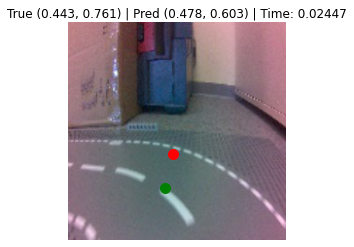

NameError: name 'model_speed' is not defined

In [11]:
angle = 0.0
angle_last = 0.0

def preprocess(image):
    image = PIL.Image.fromarray(image)
    image = transforms.functional.to_tensor(image).to(device).half()
    image.sub_(mean[:, None, None]).div_(std[:, None, None])
    return image[None, ...]

def execute(change):
    global angle, angle_last
    image = change['new']
    xy = model_speed(preprocess(image)).detach().float().cpu().numpy().flatten()

    x = xy[0] - 0.5   # re-center to [-0.5, 0.5]
    y = 1-xy[1] # closer target = larger y → positive steering
    
    x_slider.value = x
    y_slider.value = y
    
    speed_slider.value = speed_gain_slider.value
    
    angle = np.arctan2(x, y)
    pid = angle * steering_gain_slider.value + (angle - angle_last) * steering_dgain_slider.value
    angle_last = angle
    
    steering_slider.value = pid + steering_bias_slider.value
    
    left_speed = max(min(speed_slider.value + steering_slider.value, 1.0), 0.0)
    right_speed = max(min(speed_slider.value - steering_slider.value, 1.0), 0.0)
    return left_speed, right_speed
    


def get_image_tensor(image_path):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),   # ResNet expects 224x224
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],   # ImageNet mean
                             [0.229, 0.224, 0.225])    # ImageNet std
    ])
    image = PIL.Image.open(image_path).convert('RGB')
    return transform(image)

model = models.resnet18(pretrained=False)
model.fc = torch.nn.Linear(512, 2)
state_dict = torch.load(BEST_MODEL_PATH, map_location='cpu')
model.load_state_dict(state_dict)
model.eval()

samples = [dataset.image_paths[i] for i in test_loader.dataset.indices]
random.shuffle(samples)

prediction_times = []
for s in samples[:20]:
    image = PIL.Image.open(s)
    width, height = image.size
    
    true_x = get_x(os.path.basename(s), width)
    true_y = get_y(os.path.basename(s), height)

    image, true_x, true_y = augment_image(image, true_x, true_y, max_crop=0.6)
    
    time = datetime.now()
    with torch.no_grad():
        output = model(get_image_tensor(s).unsqueeze(0))[0].numpy()

    prediction_time = (datetime.now() - time).total_seconds()
    prediction_times.append(prediction_time)

    pred_x, pred_y = output[0], output[1]
    
    plt.figure(figsize=(4, 4))
    plt.imshow(image)
    plt.title(f"True ({true_x:.3f}, {true_y:.3f}) | Pred ({pred_x:.3f}, {pred_y:.3f}) | Time: {prediction_time}")
    plt.scatter(true_x * width, true_y * height, color='green', label='True', s=100)
    plt.scatter(pred_x * width, pred_y * height, color='red', label='Pred', s=100)
    plt.axis('off')
    plt.show()
    

    left_speed, right_speed = execute({'new': np.array(image)})
    print(f"Left speed: {left_speed:.3f}, Right speed: {right_speed:.3f}")



